In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Define the directory you want to search in
directory = Path(
    "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\coe_dataframes\\coe_results\\multivariate_hawkes\\"
)
files = [
    file for file in directory.rglob("*") if file.is_file() and "times" not in file.name
]

In [4]:
def same_sign(a, b):
    return (a >= 0 and b >= 0) or (a < 0 and b < 0)


dfs = []
for file in files:
    fileparts = file.parts
    method = fileparts[-5]
    pair = fileparts[-4]
    param = fileparts[-3]
    bi_level = fileparts[-2]
    filename = fileparts[-1]

    prediction_df = pd.read_csv(file, sep="\t")
    real_df = pd.read_csv(
        f"C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\coe_dataframes\\simulation_dataframes\\{method}\\{pair}\\{param}\\120\\{bi_level}\\{filename}",
        sep="\t",
    )
    comparison_df = real_df.merge(prediction_df, left_on="real", right_on="time")
    comparison_df = comparison_df.dropna()

    comparison_df["Correct Prediction"] = comparison_df[
        ["predicted_return", "Return"]
    ].apply(lambda x: same_sign(x["predicted_return"], x["Return"]), axis=1)

    df = comparison_df.copy()
    df["method"] = method
    df["pair"] = pair
    df["param"] = param
    df["bi_level"] = bi_level
    df["file"] = filename

    dfs.append(df)

df_coe = pd.concat(dfs)
df_coe = df_coe[df_coe["bi_level"] == "bi_level_5"]
df_coe = df_coe.rename(columns={"real": "Time", "predicted_return": "predicted_return"})
df_coe.head()

,Time,predicted,BaseImbalance,Return,time,predicted_return,Correct Prediction,method,pair,param,bi_level,file
0,25.457,25.536094,0.238095,-0.000047,25.457,-0.000024,1.0,multivariate_hawkes,BTC_USD,training_time_1500,bi_level_5,orderbook_changes_1705356920082_1705353321.tsv
1,26.529,26.381732,0.300000,-0.000082,26.529,-0.000031,1.0,multivariate_hawkes,BTC_USD,training_time_1500,bi_level_5,orderbook_changes_1705356920082_1705353321.tsv
2,28.089,27.611193,0.157895,-0.000070,28.089,-0.000016,1.0,multivariate_hawkes,BTC_USD,training_time_1500,bi_level_5,orderbook_changes_1705356920082_1705353321.tsv
3,30.523,29.422784,0.066667,0.000012,30.523,-0.000007,0.0,multivariate_hawkes,BTC_USD,training_time_1500,bi_level_5,orderbook_changes_1705356920082_1705353321.tsv
4,31.838,31.661702,-0.125000,0.000035,31.838,0.000013,1.0,multivariate_hawkes,BTC_USD,training_time_1500,bi_level_5,orderbook_changes_1705356920082_1705353321.tsv


In [5]:
dfs = []

for pair in ["BTC_USD", "ETH_USD", "ETH_BTC", "BTC_USDT", "ETH_USDT"]:
    directory = Path(
        f"C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\simulations_multivariate\\multivariate_hawkes\\{pair}\\training_time_1500\\simulation_seconds_120"
    )
    files = [
        file
        for file in directory.rglob("*")
        if file.is_file() and "times" not in file.name
    ]

    for file in files:
        df = pd.read_csv(file, sep="\t")
        df["file"] = file
        df["pair"] = pair
        dfs.append(df)

df_hawkes = pd.concat(dfs)
df_hawkes["Predicted Event Type"] = df_hawkes[
    ["Predicted MP UP Time", "Predicted MP DOWN Time"]
].apply(
    lambda x: (
        "MID_PRICE_UP"
        if x["Predicted MP UP Time"] < x["Predicted MP DOWN Time"]
        else "MID_PRICE_DOWN"
    ),
    axis=1,
)
df_hawkes["Correct Prediction"] = (
    df_hawkes["Predicted Event Type"] == df_hawkes["Real Event Type"]
)
df_hawkes = df_hawkes.rename(columns={"Real Event Time": "Time"})
df_hawkes.head()

,Time,Real Event Type,Predicted MP UP Time,Predicted MP DOWN Time,Real Time Previous Event,Real Type Previous Event,Return,file,pair,Predicted Event Type,Correct Prediction
0,151.150,MID_PRICE_UP,162.534880,151.467877,150.678,MID_PRICE_DOWN,0.000023,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_DOWN,False
1,151.382,MID_PRICE_UP,163.186839,157.599259,151.150,SELL_PRESSURE_UP,-0.000012,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_DOWN,False
2,151.616,MID_PRICE_DOWN,151.850567,157.209817,151.150,MID_PRICE_UP,0.000023,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_UP,False
3,152.026,MID_PRICE_UP,152.426964,157.607665,151.617,MID_PRICE_UP,-0.000012,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_UP,True
4,152.514,MID_PRICE_DOWN,156.113129,154.890946,152.291,SELL_PRESSURE_UP,-0.000047,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_DOWN,True


In [6]:
dfs = []
for file in Path(
    "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\coe_dataframes\\benchmark"
).glob("*"):
    df = pd.read_csv(file, sep="\t")
    df["file"] = file.name
    df["Correct Prediction"] = df[["AvgPastReturn", "Return"]].apply(
        lambda x: same_sign(x["AvgPastReturn"], x["Return"]), axis=1
    )
    df["pair"] = "BTC_USD"
    dfs.append(df)

df_benchmark = pd.concat(dfs)
df_benchmark = df_benchmark.rename(columns={"Timestamp": "Time"})
df_benchmark.head()

,Time,BaseImbalance,MidPrice,Return,AvgPastReturn,file,Correct Prediction,pair
0,1500.029,-0.076923,42853.5,0.000035,-0.000005,orderbook_changes_1705356920082_1705353321.tsv,False,BTC_USD
1,1500.242,-0.166667,42852.0,-0.000035,-0.000002,orderbook_changes_1705356920082_1705353321.tsv,True,BTC_USD
2,1500.462,-0.076923,42853.5,0.000035,-0.000007,orderbook_changes_1705356920082_1705353321.tsv,False,BTC_USD
3,1500.678,-0.166667,42852.0,-0.000035,0.000002,orderbook_changes_1705356920082_1705353321.tsv,False,BTC_USD
4,1500.894,0.200000,42855.5,0.000082,-0.000007,orderbook_changes_1705356920082_1705353321.tsv,False,BTC_USD


In [7]:
def trading_simulation(df):
    initial_capital = 1000
    records = []

    for file in df["file"].unique():
        for pair in df["pair"].unique():
            capital = initial_capital
            df_subset = df[(df["file"] == file) & (df["pair"] == pair)].sort_values(
                by="Time"
            )

            for _, row in df_subset.iterrows():
                if row["Correct Prediction"]:
                    capital *= 1 + abs(row["Return"])  # Increase capital
                else:
                    capital *= 1 - abs(row["Return"])  # Decrease capital

                records.append(
                    {
                        "Time": row["Time"],
                        "Capital": capital,
                        "File": file,
                        "Pair": pair,
                    }
                )

    return pd.DataFrame(records)

In [8]:
def trading_simulation(df):
    initial_capital = 1000
    records = []

    for file in df["file"].unique():
        for pair in df["pair"].unique():
            capital = initial_capital
            df_subset = df[(df["file"] == file) & (df["pair"] == pair)].sort_values(
                by="Time"
            )

            if df_subset.empty:
                continue

            records.append(
                {"Time": 0, "Capital": initial_capital, "File": file, "Pair": pair}
            )  # Force same start

            start_time = df_subset["Time"].min()
            df_subset["Time"] = df_subset["Time"] - start_time  # Normalize start times

            for _, row in df_subset.iterrows():
                if row["Correct Prediction"]:
                    capital += 1000 * abs(row["Return"])  # Increase capital
                else:
                    capital -= 1000 * abs(row["Return"])  # Decrease capital

                records.append(
                    {
                        "Time": row["Time"],
                        "Capital": capital,
                        "File": file,
                        "Pair": pair,
                    }
                )

    return pd.DataFrame(records)


trading_simulation_coe_df = trading_simulation(df_coe)
trading_simulation_hawkes = trading_simulation(df_hawkes)
trading_simulation_benchmark = trading_simulation(df_benchmark)


def plot_capital_evolution(df, pair):
    df_pair = df[df["Pair"] == pair]

    # Resample times to a common grid using interpolation
    common_times = sorted(df_pair["Time"].unique())
    df_interpolated = (
        df_pair.pivot_table(index="Time", columns="File", values="Capital")
        .reindex(common_times)
        .interpolate()
    )

    df_mean = df_interpolated.mean(axis=1)
    df_std = df_interpolated.std(axis=1)

    plt.figure(figsize=(10, 5))
    sns.lineplot(x=common_times, y=df_mean, label="Mean Capital")
    plt.fill_between(
        common_times, df_mean - df_std, df_mean + df_std, alpha=0.3, label="Std Dev"
    )
    plt.xlabel("Time")
    plt.ylabel("Capital")
    plt.title(f"Capital Evolution for Pair: {pair}")
    plt.legend()
    plt.show()

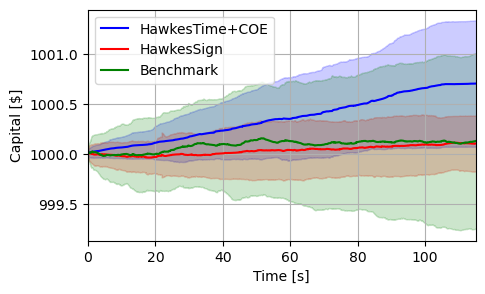

In [9]:
def plot_capital_evolution(
    df1, df2, df3, pair, label1="Dataset 1", label2="Dataset 2", label3="Dataset 3"
):
    df1_pair = df1[df1["Pair"] == pair]
    df2_pair = df2[df2["Pair"] == pair]
    df3_pair = df3[df3["Pair"] == pair]

    # Resample times to a common grid using interpolation
    common_times = sorted(
        set(df1_pair["Time"].unique())
        | set(df2_pair["Time"].unique())
        | set(df3_pair["Time"].unique())
    )

    df1_interpolated = (
        df1_pair.pivot_table(index="Time", columns="File", values="Capital")
        .reindex(common_times)
        .interpolate()
    )
    df2_interpolated = (
        df2_pair.pivot_table(index="Time", columns="File", values="Capital")
        .reindex(common_times)
        .interpolate()
    )
    df3_interpolated = (
        df3_pair.pivot_table(index="Time", columns="File", values="Capital")
        .reindex(common_times)
        .interpolate()
    )

    df1_mean = df1_interpolated.mean(axis=1)
    df1_std = df1_interpolated.std(axis=1)
    df2_mean = df2_interpolated.mean(axis=1)
    df2_std = df2_interpolated.std(axis=1)
    df3_mean = df3_interpolated.mean(axis=1)
    df3_std = df3_interpolated.std(axis=1)

    plt.figure(figsize=(5, 3))
    sns.lineplot(x=common_times, y=df1_mean, label=label1, color="blue")
    plt.fill_between(
        common_times,
        df1_mean - df1_std,
        df1_mean + df1_std,
        alpha=0.2,
        color="blue",
    )

    sns.lineplot(x=common_times, y=df2_mean, label=label2, color="red")
    plt.fill_between(
        common_times,
        df2_mean - df2_std,
        df2_mean + df2_std,
        alpha=0.2,
        color="red",
    )

    sns.lineplot(x=common_times, y=df3_mean, label=label3, color="green")
    plt.fill_between(
        common_times,
        df3_mean - df3_std,
        df3_mean + df3_std,
        alpha=0.2,
        color="green",
    )

    plt.xlabel("Time [s]")
    plt.ylabel("Capital [$]")
    plt.legend()
    plt.xlim(0, 115)
    plt.grid()
    plt.savefig(
        "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\images\\returns.pdf",
        format="pdf",
        bbox_inches="tight",
    )

    plt.show()


plot_capital_evolution(
    trading_simulation_coe_df,
    trading_simulation_hawkes,
    trading_simulation_benchmark,
    "BTC_USD",
    "HawkesTime+COE",
    "HawkesSign",
    "Benchmark",
)

In [16]:
def interpolate_dataframe(df):
    # Get all unique time points across all files
    all_times = sorted(df["Time"].unique())

    # Create an empty list to store interpolated dataframes
    interpolated_dfs = []

    # Group by File
    for file_name, group in df.groupby("File"):
        # Create a new dataframe with all time points
        new_df = pd.DataFrame({"Time": all_times})

        # Merge with original data
        merged = new_df.merge(group[["Time", "Capital"]], on="Time", how="left")

        # Interpolate missing Capital values
        merged["Capital"] = merged["Capital"].interpolate(method="linear")

        # If there are still NaN values at the start or end, you can fill them
        merged["Capital"] = merged["Capital"].bfill().ffill()

        # Add the File column
        merged["File"] = file_name

        interpolated_dfs.append(merged)

    # Combine all interpolated dataframes
    result = pd.concat(interpolated_dfs, ignore_index=True)

    # Reorder columns to match original
    result = result[["Time", "Capital", "File"]]

    return result


trading_simulation_coe_df_interpolated = interpolate_dataframe(
    trading_simulation_coe_df[trading_simulation_coe_df["Pair"] == "BTC_USD"]
)
trading_simulation_hawkes_interpolated = interpolate_dataframe(
    trading_simulation_hawkes[trading_simulation_hawkes["Pair"] == "BTC_USD"]
)
trading_simulation_benchmark_interpolated = interpolate_dataframe(
    trading_simulation_benchmark[trading_simulation_benchmark["Pair"] == "BTC_USD"]
)

In [33]:
import numpy as np


capital_matrix_coe = np.vstack(
    trading_simulation_coe_df_interpolated.groupby("File")["Capital"].apply(
        lambda x: x.to_numpy()
    )
)
capital_matrix_hawkes = np.vstack(
    trading_simulation_hawkes_interpolated.groupby("File")["Capital"].apply(
        lambda x: x.to_numpy()
    )
)
capital_matrix_benchmark = np.vstack(
    trading_simulation_benchmark_interpolated.groupby("File")["Capital"].apply(
        lambda x: x.to_numpy()
    )
)

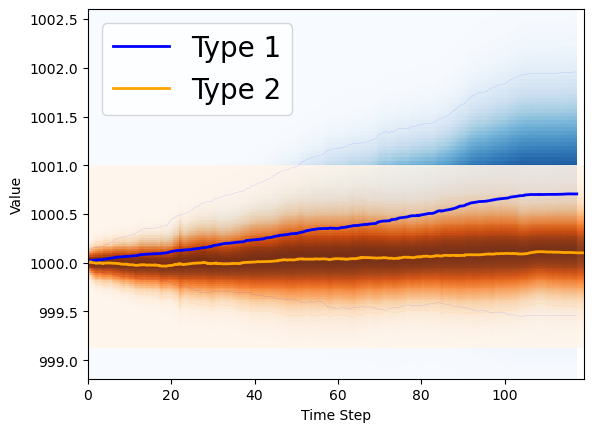

In [45]:
import numpy as np
from scipy.stats import norm


time_series_matrices = [
    (
        trading_simulation_coe_df_interpolated[
            trading_simulation_coe_df_interpolated["File"]
            == trading_simulation_coe_df_interpolated["File"][0]
        ]["Time"].values,
        capital_matrix_coe,
    ),
    (
        trading_simulation_hawkes_interpolated[
            trading_simulation_hawkes_interpolated["File"]
            == trading_simulation_hawkes_interpolated["File"][0]
        ]["Time"].values,
        capital_matrix_hawkes,
    ),
    # (
    #    trading_simulation_benchmark_interpolated[
    #        trading_simulation_benchmark_interpolated["File"]
    #        == trading_simulation_benchmark_interpolated["File"][0]
    #    ]["Time"].values,
    #    capital_matrix_benchmark,
    # ),
]
colors = ["blue", "orange", "red", "purple", "orange"]
colormaps = ["Blues", "Oranges", "Reds", "Purples", "Oranges"]

for idx, time_series_matrix in enumerate(time_series_matrices):
    time_axis = time_series_matrix[0]
    time_series = time_series_matrix[1]
    # Calculate the mean and standard deviation of the perturbed series at each time step
    perturbed_mean = np.mean(time_series, axis=0)
    perturbed_std = np.std(time_series, axis=0)

    # Plot the average time series
    plt.plot(
        time_axis,
        perturbed_mean,
        label=f"Type {idx + 1}",
        color=colors[idx],
        linewidth=2,
    )

    # Create a grid for the shaded area
    x = np.linspace(
        np.min(perturbed_mean - 3 * perturbed_std),
        np.max(perturbed_mean + 3 * perturbed_std),
        100,
    )
    time_grid, x_grid = np.meshgrid(time_axis, x)

    # Compute the PDF for each time step and value in the grid
    pdf_values = np.zeros_like(x_grid)
    for i, t in enumerate(time_axis):
        if i != 0:
            dist = norm(loc=perturbed_mean[i], scale=perturbed_std[i])
            pdf_values[:, i] = dist.pdf(x_grid[:, i])

    # Normalize the PDF values for better contrast
    pdf_values_normalized = pdf_values / np.where(
        np.max(pdf_values, axis=0) != 0, np.max(pdf_values, axis=0), 1
    )

    # Plot the shaded area as a continuous tube
    plt.pcolormesh(
        time_grid,
        x_grid,
        pdf_values_normalized,
        shading="auto",
        cmap=colormaps[idx],
        alpha=0.9,
    )

    # Add light lines to delimit the shaded area (e.g., mean ± 2 standard deviations)
    upper_bound = perturbed_mean + 2 * perturbed_std
    lower_bound = perturbed_mean - 2 * perturbed_std
    plt.plot(
        time_axis,
        upper_bound,
        color=colors[idx],
        linestyle="--",
        linewidth=0.1,
        alpha=0.7,
    )
    plt.plot(
        time_axis,
        lower_bound,
        color=colors[idx],
        linestyle="--",
        linewidth=0.1,
        alpha=0.7,
    )

# Add labels and legend
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.xlim([0, time_axis[-1]])
plt.legend(fontsize=20)

# Show the plot
plt.show()

In [28]:
pdf_values_normalized

array([[0.00000000e+00, 1.62707082e-98, 1.60246680e-93, ...,
        1.00707728e-03, 1.00753513e-03, 1.00766164e-03],
       [0.00000000e+00, 2.33232427e-92, 1.08997964e-87, ...,
        1.20575006e-03, 1.20623164e-03, 1.20636785e-03],
       [0.00000000e+00, 2.10884159e-86, 4.79440523e-82, ...,
        1.43832053e-03, 1.43881802e-03, 1.43896285e-03],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.43367965e-03, 1.43803993e-03, 1.43896285e-03],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.20177782e-03, 1.20556560e-03, 1.20636785e-03],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.00369126e-03, 1.00696734e-03, 1.00766164e-03]])

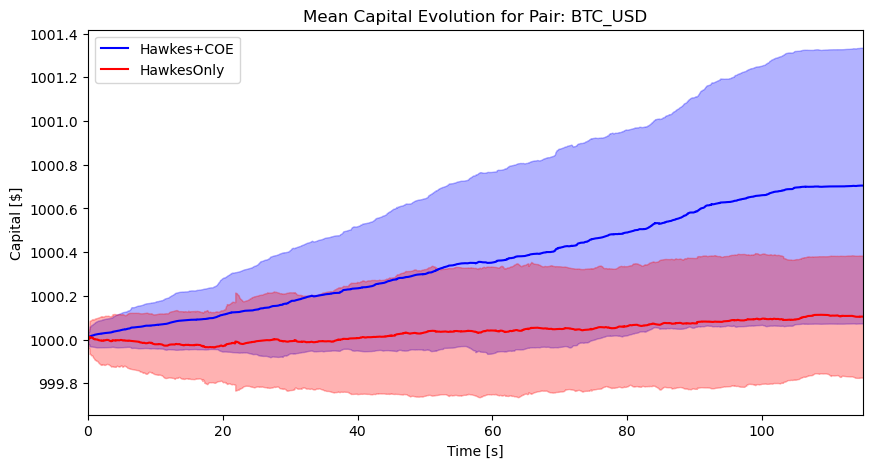

In [ ]:
def plot_capital_evolution(df1, df2, pair, label1="Dataset 1", label2="Dataset 2"):
    df1_pair = df1[df1["Pair"] == pair]
    df2_pair = df2[df2["Pair"] == pair]

    # Resample times to a common grid using interpolation
    common_times = sorted(
        set(df1_pair["Time"].unique()) | set(df2_pair["Time"].unique())
    )

    df1_interpolated = (
        df1_pair.pivot_table(index="Time", columns="File", values="Capital")
        .reindex(common_times)
        .interpolate()
    )
    df2_interpolated = (
        df2_pair.pivot_table(index="Time", columns="File", values="Capital")
        .reindex(common_times)
        .interpolate()
    )

    df1_mean = df1_interpolated.mean(axis=1)
    df1_std = df1_interpolated.std(axis=1)
    df2_mean = df2_interpolated.mean(axis=1)
    df2_std = df2_interpolated.std(axis=1)

    plt.figure(figsize=(10, 5))
    sns.lineplot(x=common_times, y=df1_mean, label=label1, color="blue")
    plt.fill_between(
        common_times, df1_mean - df1_std, df1_mean + df1_std, alpha=0.3, color="blue"
    )

    sns.lineplot(x=common_times, y=df2_mean, label=label2, color="red")
    plt.fill_between(
        common_times, df2_mean - df2_std, df2_mean + df2_std, alpha=0.3, color="red"
    )

    plt.xlabel("Time [s]")
    plt.ylabel("Capital [$]")
    plt.title(f"Mean Capital Evolution for Pair: {pair}")
    plt.legend()
    plt.xlim(0, 115)
    plt.show()


plot_capital_evolution(
    trading_simulation_coe_df,
    trading_simulation_hawkes,
    "BTC_USD",
    "Hawkes+COE",
    "HawkesOnly",
)

In [ ]:
# import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# needed to eliminate the type 3 font issue
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
import warnings
from tqdm import tqdm

warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["xtick.labelsize"] = 18
plt.rcParams["ytick.labelsize"] = 18
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.xmargin"] = 0
from scipy.stats import norm


def plot_multiple_time_series_with_distribution(
    time_series_matrices, num_perturbations=100, noise_std=0.5
):
    """
    Plots multiple types of time series, each with its own average, shaded tube, and delimiting lines.

    Parameters:
    time_series_matrices (list of numpy arrays): A list of N matrices, where each matrix contains K scenarios
                                               of the n-th type of time series.
    num_perturbations (int): Number of perturbed time series to generate for each type.
    noise_std (float): Standard deviation of the noise added to the average time series.
    """
    # Define a color palette and corresponding colormaps for different types
    colors = ["blue", "green", "red", "purple", "orange"]
    colormaps = ["Blues", "Greens", "Reds", "Purples", "Oranges"]

    # Create a time axis (assuming all time series have the same length)
    time_axis = np.arange(time_series_matrices[0].shape[1])

    # Plot each type of time series
    for idx, time_series_matrix in enumerate(time_series_matrices):
        # Calculate the average time series for the current type
        mean_time_series = np.mean(time_series_matrix, axis=0)

        # Generate perturbed versions of the average time series
        perturbed_series = np.array(
            [
                mean_time_series
                + np.random.normal(0, noise_std, size=mean_time_series.shape)
                for _ in range(num_perturbations)
            ]
        )

        # Calculate the mean and standard deviation of the perturbed series at each time step
        perturbed_mean = np.mean(perturbed_series, axis=0)
        perturbed_std = np.std(perturbed_series, axis=0)

        # Plot the average time series
        plt.plot(
            time_axis,
            mean_time_series,
            label=f"Type {idx + 1}",
            color=colors[idx],
            linewidth=2,
        )

        # Create a grid for the shaded area
        x = np.linspace(
            np.min(perturbed_mean - 3 * perturbed_std),
            np.max(perturbed_mean + 3 * perturbed_std),
            100,
        )
        time_grid, x_grid = np.meshgrid(time_axis, x)

        # Compute the PDF for each time step and value in the grid
        pdf_values = np.zeros_like(x_grid)
        for t in time_axis:
            dist = norm(loc=perturbed_mean[t], scale=perturbed_std[t])
            pdf_values[:, t] = dist.pdf(x_grid[:, t])

        # Normalize the PDF values for better contrast
        pdf_values_normalized = pdf_values / np.max(pdf_values)

        # Plot the shaded area as a continuous tube
        plt.pcolormesh(
            time_grid,
            x_grid,
            pdf_values_normalized,
            shading="auto",
            cmap=colormaps[idx],
            alpha=0.4,
        )

        # Add light lines to delimit the shaded area (e.g., mean ± 2 standard deviations)
        upper_bound = perturbed_mean + 2 * perturbed_std
        lower_bound = perturbed_mean - 2 * perturbed_std
        plt.plot(
            time_axis,
            upper_bound,
            color=colors[idx],
            linestyle="--",
            linewidth=0.1,
            alpha=0.7,
        )
        plt.plot(
            time_axis,
            lower_bound,
            color=colors[idx],
            linestyle="--",
            linewidth=0.1,
            alpha=0.7,
        )

    # Add labels and legend
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.xlim([0, time_axis[-1]])
    plt.legend(fontsize=20)

    # Show the plot
    plt.show()

ModuleNotFoundError: No module named 'tqdm'